In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

local_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1-2. [Lead] Triboresistive sensor\1. [Lead] DC TRS\1. 실험자료\260724_DC 원인 파악 시작\0minimized_csv파일\3x3_DC_3.csv"


max value: 0.2944
min value: -0.5032


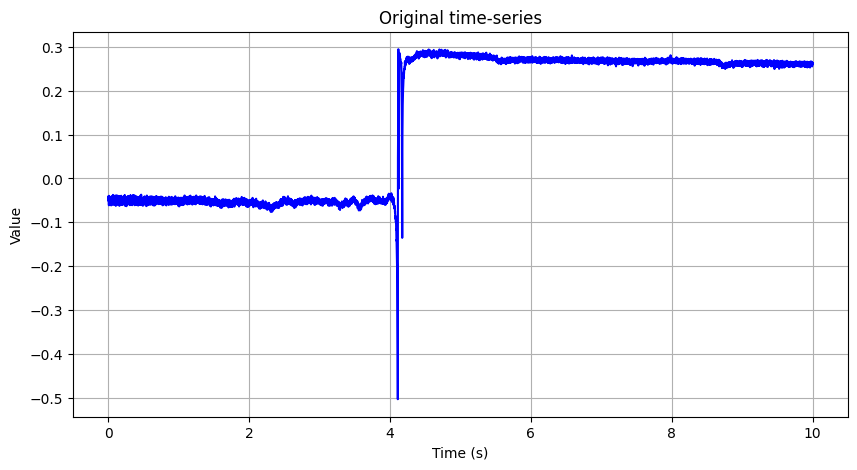

In [102]:
df = pd.read_csv(local_path, header=None, usecols=[0, 1])
df.columns = ["Time", "Value"]

# 데이터 형식 변환: 문자값은 NaN 처리
df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.dropna(subset=["Time", "Value"]).reset_index(drop=True)

print(f"max value: {df['Value'].max():.4f}")
print(f"min value: {df['Value'].min():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("Original time-series")
plt.grid(True)
plt.show()


In [103]:
# 평균을 구할 시간 범위 지정
time_range = (0, 1)  # MODIFY HERE


Selected range: 0.000000 s ~ 1.000000 s
Average value: -0.049974


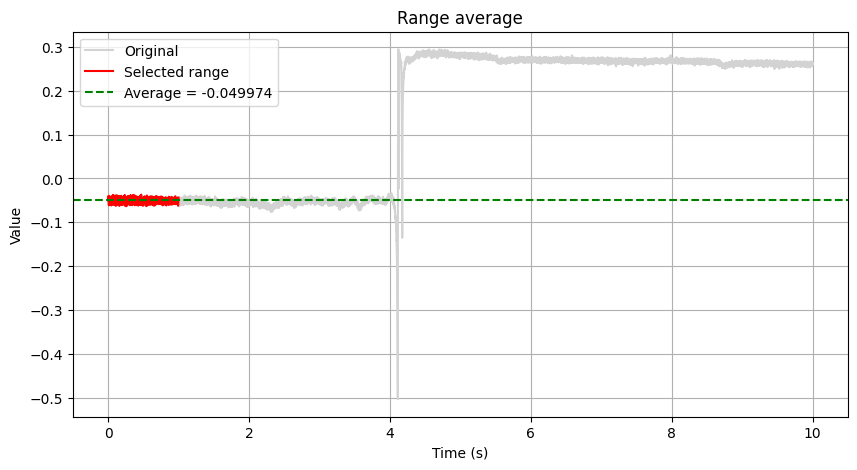

In [104]:
df_selected = df[(df["Time"] >= time_range[0]) & (df["Time"] <= time_range[1])].copy()

if df_selected.empty:
    raise ValueError("지정한 범위에 데이터가 없습니다. time_range를 확인하세요.")

average_value = df_selected["Value"].mean()
start_time = df_selected["Time"].iloc[0]
end_time = df_selected["Time"].iloc[-1]

print(f"Selected range: {start_time:.6f} s ~ {end_time:.6f} s")
print(f"Average value: {average_value:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="lightgray", label="Original")
plt.plot(df_selected["Time"], df_selected["Value"], color="r", label="Selected range")
plt.axhline(average_value, color="g", linestyle="--", label=f"Average = {average_value:.6f}")
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("Range average")
plt.legend()
plt.grid(True)
plt.show()
